In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [48]:
df = pd.read_excel(r"C:\Users\ASSULT 1\Downloads\data.xlsx")

print(df.head())
print(df.shape)
print(df.info())

   Unnamed: 0      ID               Name  Age  \
0           0  158023           L. Messi   31   
1           1   20801  Cristiano Ronaldo   33   
2           2  190871          Neymar Jr   26   
3           3  193080             De Gea   27   
4           4  192985       K. De Bruyne   27   

                                            Photo Nationality  \
0  https://cdn.sofifa.org/players/4/19/158023.png   Argentina   
1   https://cdn.sofifa.org/players/4/19/20801.png    Portugal   
2  https://cdn.sofifa.org/players/4/19/190871.png      Brazil   
3  https://cdn.sofifa.org/players/4/19/193080.png       Spain   
4  https://cdn.sofifa.org/players/4/19/192985.png     Belgium   

                                  Flag  Overall  Potential  \
0  https://cdn.sofifa.org/flags/52.png       94         94   
1  https://cdn.sofifa.org/flags/38.png       94         94   
2  https://cdn.sofifa.org/flags/54.png       92         93   
3  https://cdn.sofifa.org/flags/45.png       91         93   
4   

In [49]:
print(df.isnull().sum())

# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Unnamed: 0           0
ID                   0
Name                 0
Age                  0
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64


C:\Users\ASSULT 1\AppData\Local\Temp\ipykernel_2192\1562555667.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\ASSULT 1\AppData\Local\Temp\ipykernel_2192\1562555667.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [50]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [51]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers Removed")

Outliers Removed


In [52]:
print(df[num_cols].skew())

Unnamed: 0                 -0.033447
ID                         -0.852891
Age                         0.338429
Overall                    -0.201036
Potential                   0.183781
Special                    -0.012256
International Reputation    0.000000
Weak Foot                   0.000000
Skill Moves                 0.449842
Jersey Number               0.528308
Crossing                   -0.436228
Finishing                  -0.339491
HeadingAccuracy            -0.143019
ShortPassing               -0.463920
Volleys                     0.029140
Dribbling                  -0.430040
Curve                      -0.026274
FKAccuracy                  0.375209
LongPassing                -0.577771
BallControl                -0.268833
Acceleration               -0.099469
SprintSpeed                -0.033868
Agility                    -0.128854
Reactions                  -0.143843
Balance                    -0.145340
ShotPower                  -0.502205
Jumping                    -0.032781
S

In [53]:
skew_cols = df[num_cols].skew()

skew_cols = skew_cols[abs(skew_cols) > 1].index

for col in skew_cols:
    df[col] = np.log1p(df[col])

print("Skewness Fixed")

Skewness Fixed


In [54]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()

    cat_cols = df.select_dtypes(include='object').columns

    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

In [55]:
target = 'Release Clause'
top_features = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

selected_features = top_features.drop(target).index[:12]

X = df[selected_features]
y = df[target]

print(selected_features)
selected_features = top_features.drop(target).index[:12]

X = df[selected_features]
y = df[target]

print(selected_features)

X = df[selected_features]

y = df[target]

print(selected_features)

Index(['Loaned From', 'Potential', 'Unnamed: 0', 'Skill Moves', 'BallControl',
       'Overall', 'Wage', 'RF', 'CF', 'LF', 'LW', 'RW'],
      dtype='object')
Index(['Loaned From', 'Potential', 'Unnamed: 0', 'Skill Moves', 'BallControl',
       'Overall', 'Wage', 'RF', 'CF', 'LF', 'LW', 'RW'],
      dtype='object')
Index(['Loaned From', 'Potential', 'Unnamed: 0', 'Skill Moves', 'BallControl',
       'Overall', 'Wage', 'RF', 'CF', 'LF', 'LW', 'RW'],
      dtype='object')


<Figure size 1200x800 with 0 Axes>

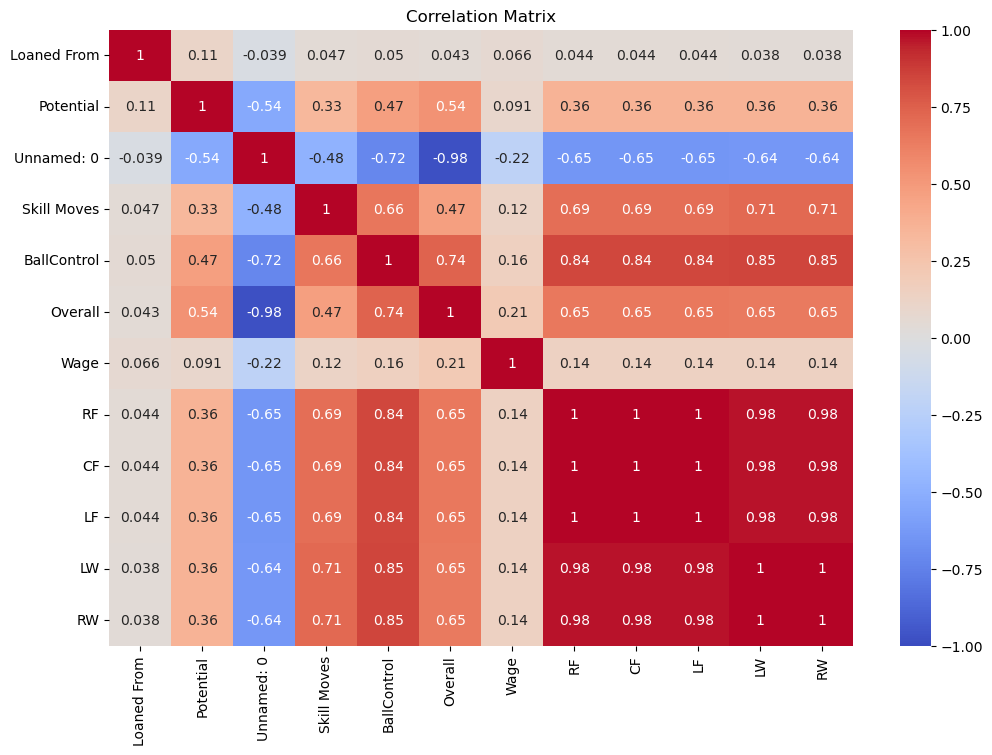

In [56]:
plt.figure(figsize=(12,8))

plt.figure(figsize=(12,8))
sns.heatmap(df[selected_features].corr(), vmax=1, vmin=-1, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4787, 12)
(2359, 12)


In [58]:
models = {

    "Linear Regression":
    LinearRegression(),

    "Decision Tree":
    DecisionTreeRegressor(random_state=42),

    "Random Forest":
    RandomForestRegressor(random_state=42),

    "Gradient Boosting":
    GradientBoostingRegressor(random_state=42),

    "KNN":
    KNeighborsRegressor(),

    "SVR":
    SVR()
}

In [59]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append(
        [name, mae, mse, rmse, r2]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
)

print(
    results_df.sort_values(
        by="R2",
        ascending=False
    )
)

               Model         MAE           MSE        RMSE        R2
2      Random Forest  108.990755  29727.811028  172.417548  0.545303
3  Gradient Boosting  140.987874  34403.711133  185.482374  0.473783
1      Decision Tree  126.590504  54114.312421  232.624832  0.172303
0  Linear Regression  206.257178  58388.748373  241.637639  0.106924
4                KNN  185.830267  58543.486223  241.957612  0.104557
5                SVR  214.398593  66811.890833  258.479962 -0.021911


In [60]:
best_model_name = results_df.sort_values(
    by="R2",
    ascending=False
).iloc[0]["Model"]

print("Best Model =", best_model_name)

Best Model = Random Forest


In [61]:
best_model = RandomForestRegressor(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
X_pred = df[selected_features].copy()

if "Joined" in X_pred.columns:
    if pd.api.types.is_datetime64_any_dtype(X_pred["Joined"]):
        joined_median = X_pred["Joined"].median()
        X_pred["Joined"] = X_pred["Joined"].fillna(joined_median)
        X_pred["Joined"] = X_pred["Joined"].astype("int64") // 10**9

df["Predicted_Rating"] = best_model.predict(X_pred)

formations = {

    "4-3-3": {
        "GK":1,
        "DEF":4,
        "MID":3,
        "FWD":3
    },

    "4-4-2": {
        "GK":1,
        "DEF":4,
        "MID":4,
        "FWD":2
    },

    "3-5-2": {
        "GK":1,
        "DEF":3,
        "MID":5,
        "FWD":2
    }
}
formations = {

    "4-3-3": {
        "GK":1,
        "DEF":4,
        "MID":3,
        "FWD":3
    },

    "4-4-2": {
        "GK":1,
        "DEF":4,
        "MID":4,
        "FWD":2
    },

    "3-5-2": {
        "GK":1,
        "DEF":3,
        "MID":5,
        "FWD":2
    }
}

In [64]:
formation_scores = {}

for formation, positions in formations.items():

    team = []

    for pos, count in positions.items():

        selected = (
            df[df["Position"] == pos]
            .sort_values(
                by="Predicted_Rating",
                ascending=False
            )
            .head(count)
        )

        team.append(selected)

    final_team = pd.concat(team)

    avg_rating = final_team[
        "Predicted_Rating"
    ].mean()

    formation_scores[
        formation
    ] = avg_rating

    print("\n")
    print("Formation:", formation)

    print(
        final_team[
            ["Name",
             "Position",
             "Predicted_Rating"]
        ]
    )



Formation: 4-3-3
Empty DataFrame
Columns: [Name, Position, Predicted_Rating]
Index: []


Formation: 4-4-2
Empty DataFrame
Columns: [Name, Position, Predicted_Rating]
Index: []


Formation: 3-5-2
Empty DataFrame
Columns: [Name, Position, Predicted_Rating]
Index: []


In [65]:
best_formation = max(
    formation_scores,
    key=formation_scores.get
)

print(
    "Best Formation:",
    best_formation
)

print(
    "Score:",
    formation_scores[
        best_formation
    ]
)

Best Formation: 4-3-3
Score: nan


In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [70]:
joblib.dump(
    best_model,
    "best_formation_model.pkl"
)

print("Model Saved")

Model Saved


In [71]:
df.to_csv("preprocessed_data.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully
